In [ ]:
# !pip3 install yfinance
import yfinance as yf
df = yf.download("AAPL", start="2015-01-01", end="2024-11-01")


  Using cached yfinance-0.2.66-py2.py3-none-any.whl.metadata (6.0 kB)
  Using cached multitasking-0.0.12-py3-none-any.whl
  Using cached frozendict-2.4.7-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (23 kB)
  Using cached peewee-3.18.3-cp310-cp310-linux_x86_64.whl
  Using cached beautifulsoup4-4.14.2-py3-none-any.whl.metadata (3.8 kB)
  Using cached curl_cffi-0.13.0-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (13 kB)
  Using cached websockets-15.0.1-cp310-cp310-manylinux_2_5_x86_64.manylinux1_x86_64.manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (6.8 kB)
  Using cached soupsieve-2.8-py3-none-any.whl.metadata (4.6 kB)
  Using cached cffi-2.0.0-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (2.6 kB)
  Using cached pycparser-2.23-py3-none-any.whl.metadata (993 bytes)
Using cached yfinance-0.2.66-py2.py3-none-any.whl (123 kB)
Using cached beautifulsoup4-4.14.2-py3-none-any.whl (106 kB)
Using ca

/tmp/ipykernel_21899/2508735212.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2015-01-01", end="2024-11-01")
[*********************100%***********************]  1 of 1 completed


In [3]:
data = df[['Close']]


In [4]:
data


Price,Close
Ticker,AAPL
Date,
2015-01-02,24.237547
2015-01-05,23.554745
2015-01-06,23.556957
2015-01-07,23.887276
2015-01-08,24.805086
...,...
2024-10-25,230.114929
2024-10-28,232.093796


In [5]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Assuming "data" contains only the Close column
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data.values)

print("Scaled shape:", scaled_data.shape)


Scaled shape: (2475, 1)


In [6]:
sequence_length = 60

X = []
y = []

for i in range(sequence_length, len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i, 0])   # previous 60 days
    y.append(scaled_data[i, 0])                     # next day

# Convert to numpy arrays
X = np.array(X)
y = np.array(y)

# Reshape X → (samples, 60, 1) for RNN/LSTM input
X = np.reshape(X, (X.shape[0], X.shape[1], 1))

print("X shape:", X.shape)   # (samples, 60, 1)
print("y shape:", y.shape)   # (samples,)


X shape: (2415, 60, 1)
y shape: (2415,)


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN

# Build the Vanilla RNN model
rnn_model = Sequential([
    SimpleRNN(64, return_sequences=False, input_shape=(60, 1)),
    Dense(1)
])

# Compile the model
rnn_model.compile(optimizer='adam', loss='mse')

# Model summary
rnn_model.summary()


2025-11-18 15:09:16.970433: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-18 15:09:16.970527: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-18 15:09:17.025220: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-18 15:09:17.156950: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-18 15:09:19.282205: W tensorflow/compiler/tf2

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn (SimpleRNN)      (None, 64)                4224      
                                                                 
 dense (Dense)               (None, 1)                 65        
                                                                 
Total params: 4289 (16.75 KB)
Trainable params: 4289 (16.75 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [8]:
# Split into train and test (80/20)
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
y_train = y[:train_size]
X_test  = X[train_size:]
y_test  = y[train_size:]

print("Train shapes:", X_train.shape, y_train.shape)
print("Test shapes:", X_test.shape, y_test.shape)

# Train the Vanilla RNN model
history_rnn = rnn_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)


Train shapes: (1932, 60, 1) (1932,)
Test shapes: (483, 60, 1) (483,)
Epoch 1/50
61/61 [==============================] - 2s 17ms/step - loss: 0.0083 - val_loss: 0.0073
Epoch 2/50
61/61 [==============================] - 1s 11ms/step - loss: 3.3084e-04 - val_loss: 0.0040
Epoch 3/50
61/61 [==============================] - 1s 11ms/step - loss: 3.0144e-04 - val_loss: 0.0045
Epoch 4/50
61/61 [==============================] - 1s 11ms/step - loss: 2.8028e-04 - val_loss: 0.0038
Epoch 5/50
61/61 [==============================] - 1s 11ms/step - loss: 2.7670e-04 - val_loss: 0.0041
Epoch 6/50
61/61 [==============================] - 1s 12ms/step - loss: 2.5558e-04 - val_loss: 0.0043
Epoch 7/50
61/61 [==============================] - 1s 12ms/step - loss: 2.3491e-04 - val_loss: 0.0024
Epoch 8/50
61/61 [==============================] - 1s 12ms/step - loss: 2.2776e-04 - val_loss: 0.0016
Epoch 9/50
61/61 [==============================] - 1s 12ms/step - loss: 2.1406e-04 - val_loss: 0.0016
Epoch 10

In [9]:
# Make predictions on the test set
rnn_predictions = rnn_model.predict(X_test)

# Convert predictions back to original price scale
rnn_predictions = scaler.inverse_transform(rnn_predictions)

# Convert y_test back also (for fair comparison)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

print("Predictions shape:", rnn_predictions.shape)
print("Actual test shape:", y_test_actual.shape)


16/16 [==============================] - 0s 5ms/step
Predictions shape: (483, 1)
Actual test shape: (483, 1)


In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# MAE
rnn_mae = mean_absolute_error(y_test_actual, rnn_predictions)

# RMSE
rnn_rmse = np.sqrt(mean_squared_error(y_test_actual, rnn_predictions))

print("RNN MAE :", rnn_mae)
print("RNN RMSE:", rnn_rmse)


RNN MAE : 3.414774482047829
RNN RMSE: 4.197438144797228


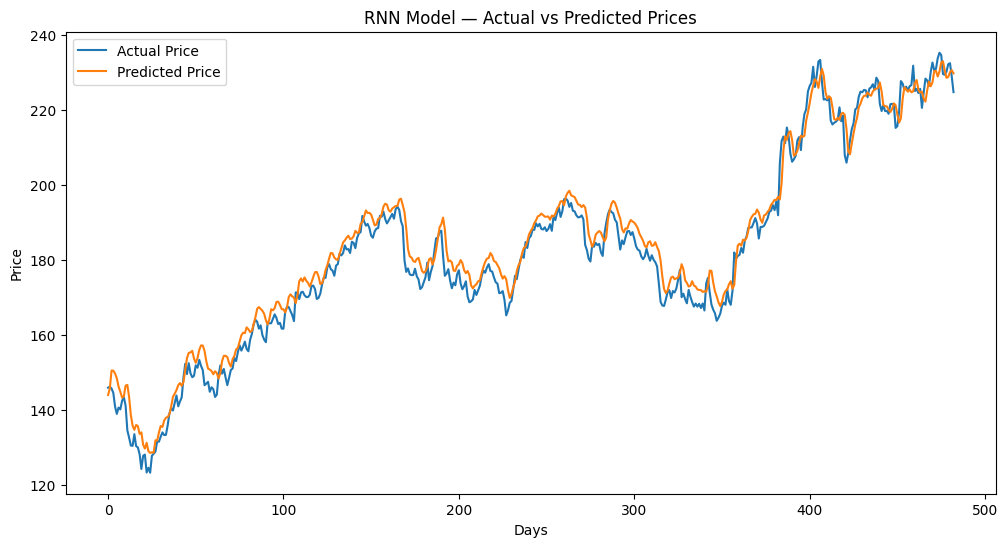

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(y_test_actual, label="Actual Price")
plt.plot(rnn_predictions, label="Predicted Price")
plt.title("RNN Model — Actual vs Predicted Prices")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()
plt.show()


Build the LSTM Model 



In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

# Build LSTM model
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(60, 1)),
    LSTM(32, return_sequences=False),
    Dense(1)
])

# Compile
lstm_model.compile(optimizer='adam', loss='mse')

# Summary
lstm_model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 60, 64)            16896     
                                                                 
 lstm_1 (LSTM)               (None, 32)                12416     
                                                                 
 dense_1 (Dense)             (None, 1)                 33        
                                                                 
Total params: 29345 (114.63 KB)
Trainable params: 29345 (114.63 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


Train the LSTM Model 

In [13]:
history_lstm = lstm_model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)


Epoch 1/50
61/61 [==============================] - 7s 57ms/step - loss: 0.0026 - val_loss: 0.0027
Epoch 2/50
61/61 [==============================] - 3s 43ms/step - loss: 3.4306e-04 - val_loss: 0.0018
Epoch 3/50
61/61 [==============================] - 3s 43ms/step - loss: 3.4593e-04 - val_loss: 0.0022
Epoch 4/50
61/61 [==============================] - 3s 43ms/step - loss: 3.0597e-04 - val_loss: 9.3276e-04
Epoch 5/50
61/61 [==============================] - 3s 43ms/step - loss: 3.3814e-04 - val_loss: 0.0013
Epoch 6/50
61/61 [==============================] - 3s 42ms/step - loss: 2.9582e-04 - val_loss: 0.0024
Epoch 7/50
61/61 [==============================] - 3s 42ms/step - loss: 2.6224e-04 - val_loss: 7.3536e-04
Epoch 8/50
61/61 [==============================] - 3s 43ms/step - loss: 2.4181e-04 - val_loss: 6.4907e-04
Epoch 9/50
61/61 [==============================] - 3s 44ms/step - loss: 2.2331e-04 - val_loss: 7.7290e-04
Epoch 10/50
61/61 [==============================] - 3s 42ms/

In [14]:
# LSTM Predictions
lstm_predictions = lstm_model.predict(X_test)

# Convert back to original price scale
lstm_predictions = scaler.inverse_transform(lstm_predictions)

print("LSTM Predictions shape:", lstm_predictions.shape)


16/16 [==============================] - 1s 14ms/step
LSTM Predictions shape: (483, 1)


In [15]:
lstm_mae = mean_absolute_error(y_test_actual, lstm_predictions)
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, lstm_predictions))

print("LSTM MAE :", lstm_mae)
print("LSTM RMSE:", lstm_rmse)


LSTM MAE : 2.372404078765932
LSTM RMSE: 3.0634933908941715


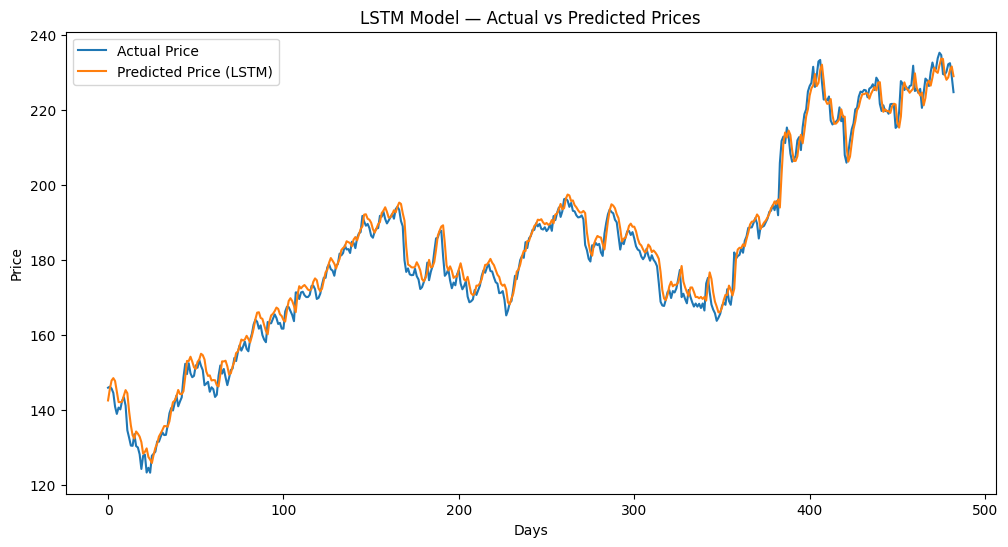

In [16]:
plt.figure(figsize=(12,6))
plt.plot(y_test_actual, label="Actual Price")
plt.plot(lstm_predictions, label="Predicted Price (LSTM)")
plt.title("LSTM Model — Actual vs Predicted Prices")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()
plt.show()


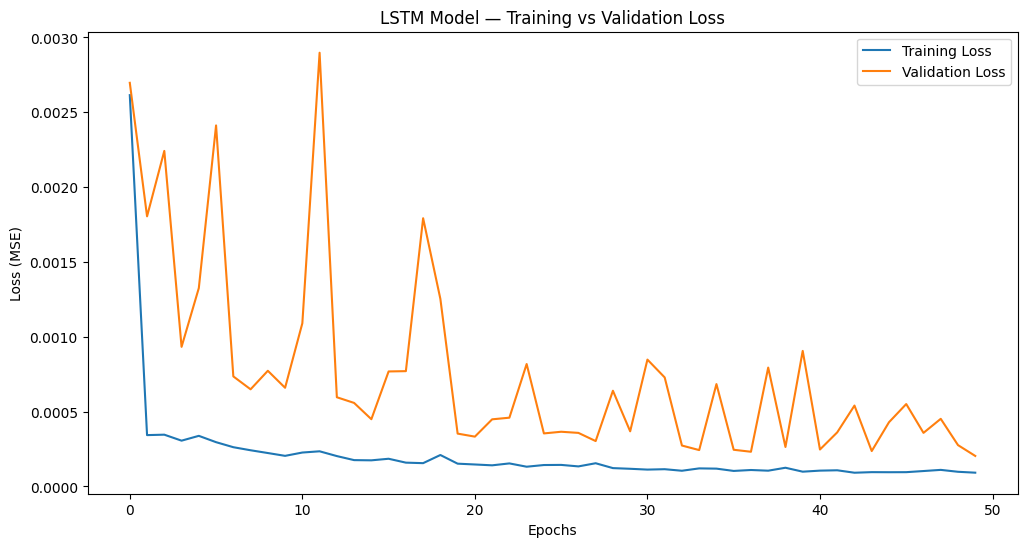

In [17]:
plt.figure(figsize=(12,6))
plt.plot(history_lstm.history['loss'], label='Training Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.title("LSTM Model — Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.show()


===== RNN Performance =====
RNN MAE : 3.414774482047829
RNN RMSE: 4.197438144797228

===== LSTM Performance =====
LSTM MAE : 2.372404078765932
LSTM RMSE: 3.0634933908941715


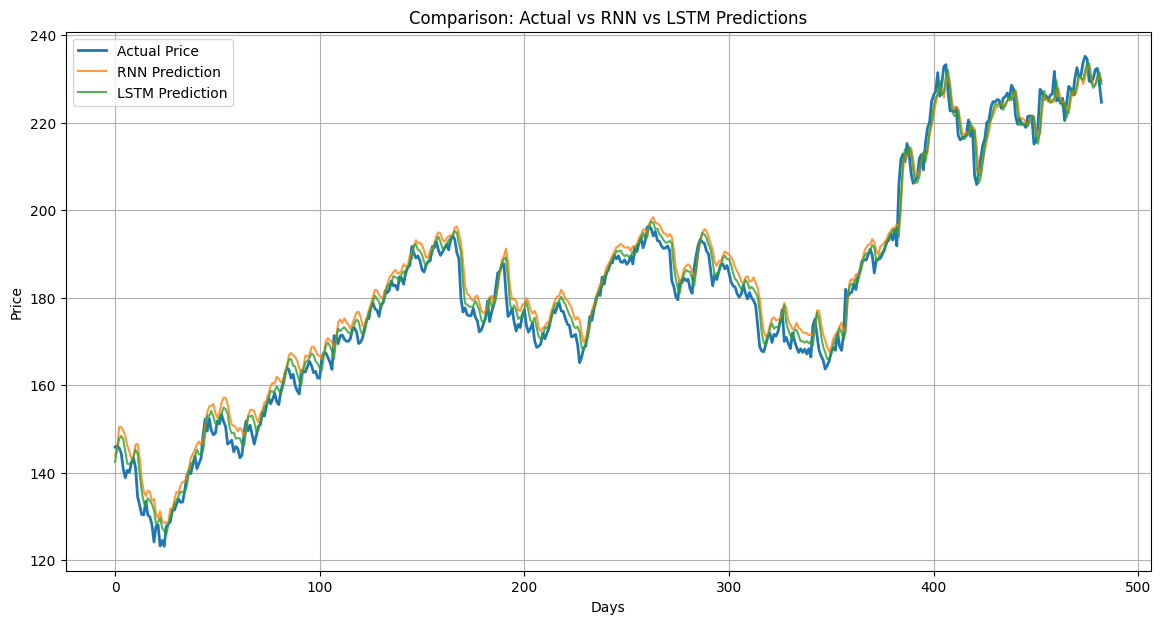

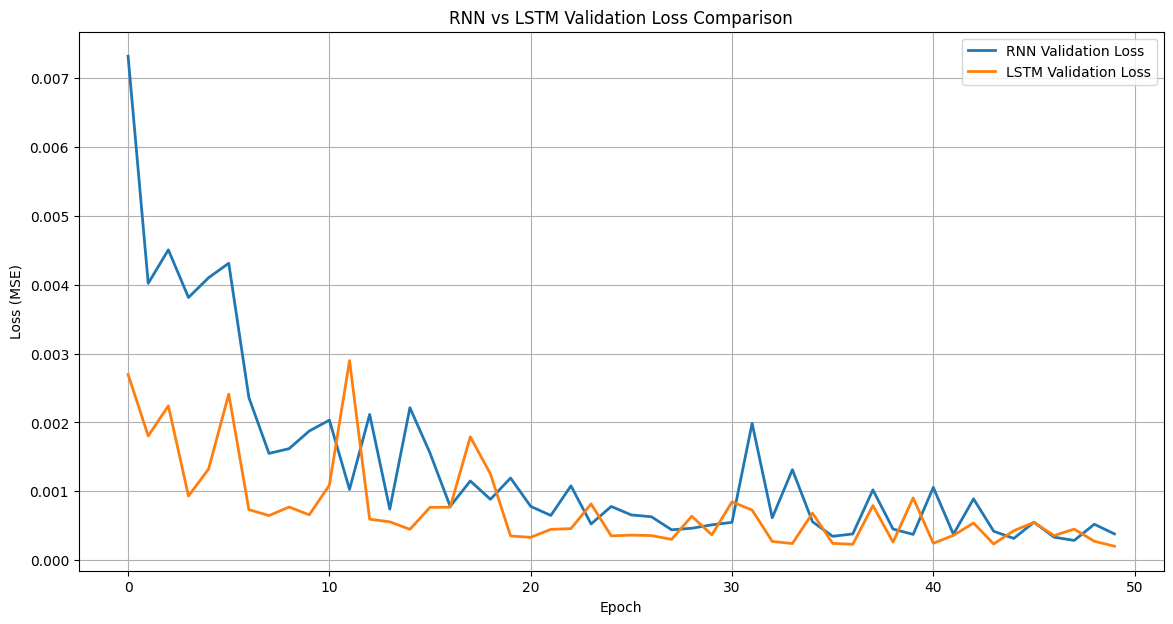

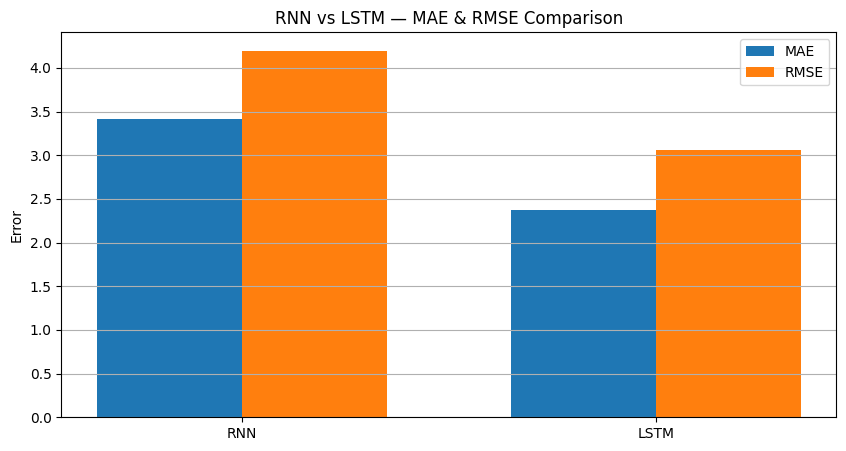

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# --------------------------------------------
# 1) Compute Metrics for Both Models
# --------------------------------------------

rnn_mae = mean_absolute_error(y_test_actual, rnn_predictions)
rnn_rmse = np.sqrt(mean_squared_error(y_test_actual, rnn_predictions))

lstm_mae = mean_absolute_error(y_test_actual, lstm_predictions)
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, lstm_predictions))

print("===== RNN Performance =====")
print("RNN MAE :", rnn_mae)
print("RNN RMSE:", rnn_rmse)

print("\n===== LSTM Performance =====")
print("LSTM MAE :", lstm_mae)
print("LSTM RMSE:", lstm_rmse)

# --------------------------------------------
# 2) Plot Actual vs Predicted (Both Models)
# --------------------------------------------

plt.figure(figsize=(14,7))
plt.plot(y_test_actual, label="Actual Price", linewidth=2)
plt.plot(rnn_predictions, label="RNN Prediction", alpha=0.8)
plt.plot(lstm_predictions, label="LSTM Prediction", alpha=0.8)
plt.title("Comparison: Actual vs RNN vs LSTM Predictions")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

# --------------------------------------------
# 3) Compare Training vs Validation Loss (Both Models)
# --------------------------------------------

plt.figure(figsize=(14,7))
plt.plot(history_rnn.history['val_loss'], label='RNN Validation Loss', linewidth=2)
plt.plot(history_lstm.history['val_loss'], label='LSTM Validation Loss', linewidth=2)
plt.title("RNN vs LSTM Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)
plt.show()

# --------------------------------------------
# 4) Bar Chart of Metrics
# --------------------------------------------

models = ['RNN', 'LSTM']
mae_values = [rnn_mae, lstm_mae]
rmse_values = [rnn_rmse, lstm_rmse]

plt.figure(figsize=(10,5))
bar_width = 0.35
indices = np.arange(len(models))

plt.bar(indices, mae_values, bar_width, label='MAE')
plt.bar(indices + bar_width, rmse_values, bar_width, label='RMSE')

plt.xticks(indices + bar_width/2, models)
plt.title("RNN vs LSTM — MAE & RMSE Comparison")
plt.ylabel("Error")
plt.legend()
plt.grid(axis='y')
plt.show()


In [19]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Calculate metrics
rnn_mae = mean_absolute_error(y_test_actual, rnn_predictions)
rnn_rmse = np.sqrt(mean_squared_error(y_test_actual, rnn_predictions))

lstm_mae = mean_absolute_error(y_test_actual, lstm_predictions)
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, lstm_predictions))

# Create comparison table
comparison_table = pd.DataFrame({
    "Model": ["RNN", "LSTM"],
    "MAE": [rnn_mae, lstm_mae],
    "RMSE": [rnn_rmse, lstm_rmse]
})

comparison_table


,Model,MAE,RMSE
0,RNN,3.414774,4.197438
1,LSTM,2.372404,3.063493


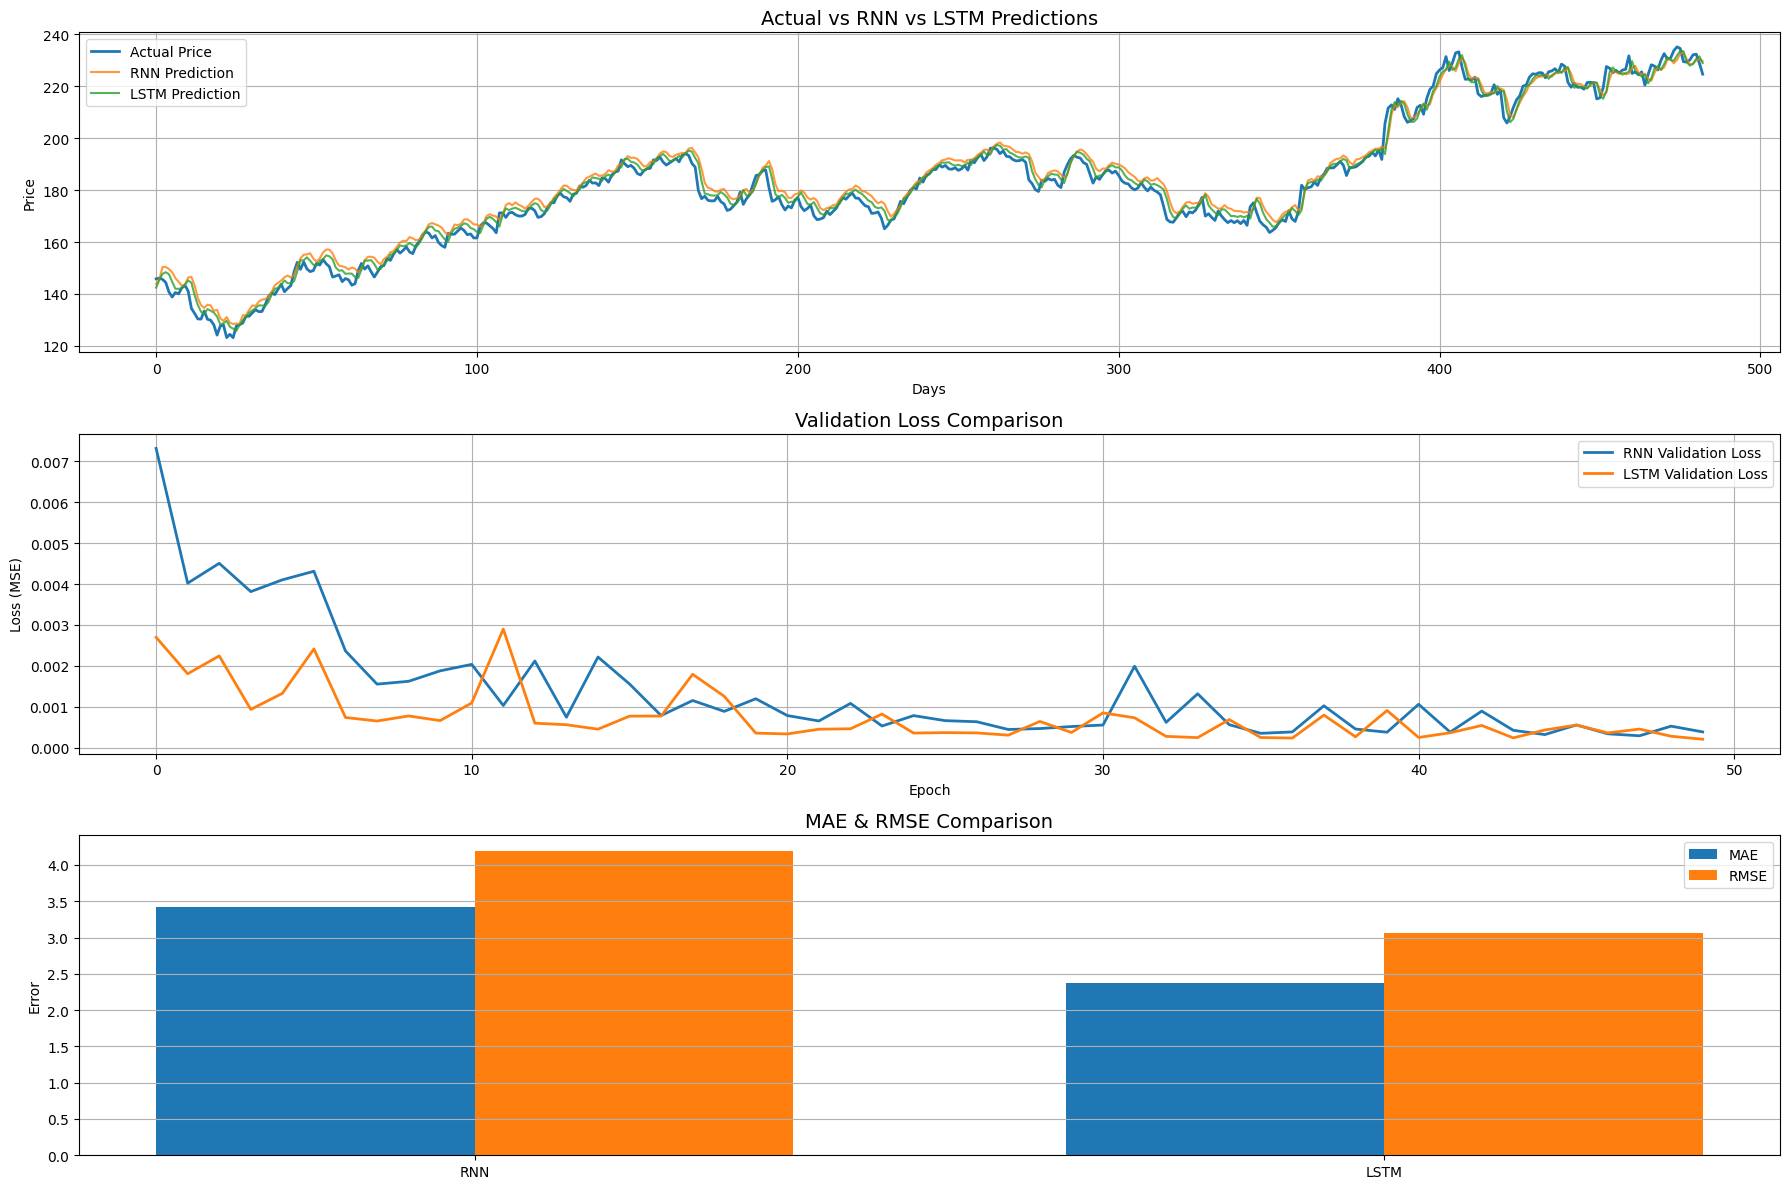

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18,12))

# -------------------------------------------------------
# Plot 1: Actual vs Predicted
# -------------------------------------------------------
plt.subplot(3,1,1)
plt.plot(y_test_actual, label="Actual Price", linewidth=2)
plt.plot(rnn_predictions, label="RNN Prediction", alpha=0.8)
plt.plot(lstm_predictions, label="LSTM Prediction", alpha=0.8)
plt.title("Actual vs RNN vs LSTM Predictions", fontsize=14)
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()
plt.grid(True)

# -------------------------------------------------------
# Plot 2: Validation Loss Comparison
# -------------------------------------------------------
plt.subplot(3,1,2)
plt.plot(history_rnn.history['val_loss'], label='RNN Validation Loss', linewidth=2)
plt.plot(history_lstm.history['val_loss'], label='LSTM Validation Loss', linewidth=2)
plt.title("Validation Loss Comparison", fontsize=14)
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True)

# -------------------------------------------------------
# Plot 3: Error Comparison Bar Chart
# -------------------------------------------------------
plt.subplot(3,1,3)
models = ["RNN", "LSTM"]
mae_values = [rnn_mae, lstm_mae]
rmse_values = [rnn_rmse, lstm_rmse]

x = np.arange(len(models))
width = 0.35

plt.bar(x - width/2, mae_values, width, label="MAE")
plt.bar(x + width/2, rmse_values, width, label="RMSE")
plt.xticks(x, models)
plt.title("MAE & RMSE Comparison", fontsize=14)
plt.ylabel("Error")
plt.legend()
plt.grid(axis='y')

plt.tight_layout()
plt.show()
